# Multilingual Speech Recognition for an Airport Assistant

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ziadelh/speech-recognition-assistant/blob/main/speech_recognition.ipynb)

A prototype of the speech recognition layer for an airport virtual assistant. It has to run **offline** (so a slow or broken internet connection cannot interrupt it), understand **English, Spanish and Italian**, and cope with a **noisy terminal**.

- **Recogniser:** [Vosk](https://alphacephei.com/vosk/), an offline toolkit with one model per language.
- **Noise handling:** a 6 dB gain and a 4 kHz low-pass filter before recognition.
- **Evaluation:** word error rate (WER) on 15 supplied airport phrases plus two sentences I recorded myself, then a test with added noise to check whether the filter really helps.

Run it top to bottom. On Colab the first cell downloads the repository and the models.

## Setup

In [1]:
import os, subprocess, sys, urllib.request, zipfile

REPO_URL = "https://github.com/ziadelh/speech-recognition-assistant.git"

# On Colab the repository is not on disk yet, so fetch it (the audio is in data/)
if not os.path.exists("data/EN/checkin.wav"):
    if not os.path.exists("speech-recognition-assistant"):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir("speech-recognition-assistant")

# install the libraries that are missing
for module, package in [("vosk", "vosk"), ("jiwer", "jiwer"), ("pydub", "pydub")]:
    try:
        __import__(module)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

# "small" runs anywhere (about 130 MB of models).
# "large" is more accurate, but needs about 5 GB of models and roughly 16 GB of RAM.
MODEL_SIZE = os.environ.get("MODEL_SIZE", "small")
print("Model size:", MODEL_SIZE)

Model size: small


In [2]:
import gc
import glob
import json
import wave

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from jiwer import wer, Compose, RemovePunctuation, ToLowerCase, RemoveMultipleSpaces
from pydub import AudioSegment
from vosk import KaldiRecognizer, Model, SetLogLevel

SetLogLevel(-1)   # keep the recogniser's log messages out of the notebook

MODELS = {
    "small": {"en": "vosk-model-small-en-us-0.15", "es": "vosk-model-small-es-0.42", "it": "vosk-model-small-it-0.22"},
    "large": {"en": "vosk-model-en-us-0.42-gigaspeech", "es": "vosk-model-es-0.42", "it": "vosk-model-it-0.22"},
}
MODEL_FOLDER = "models"

def load_model(language_code):
    """Load the Vosk model for a language, downloading it the first time."""
    name = MODELS[MODEL_SIZE][language_code.lower()]
    path = os.path.join(MODEL_FOLDER, name)
    if not os.path.isdir(path):
        os.makedirs(MODEL_FOLDER, exist_ok=True)
        print(f"Downloading {name} ...")
        urllib.request.urlretrieve(f"https://alphacephei.com/vosk/models/{name}.zip", path + ".zip")
        zipfile.ZipFile(path + ".zip").extractall(MODEL_FOLDER)
        os.remove(path + ".zip")
    return Model(path)

## Recognition and noise filtering

`transcribe_audio` feeds the audio to the recogniser in chunks and collects the text. The models are loaded once per language and passed in, because loading a large model takes a while.

`apply_filters` is the noise handling: the gain lifts quiet speech and the low-pass filter removes hiss above 4 kHz, where very little speech energy sits.

In [3]:
def transcribe_audio(audio_path, model):
    wf = wave.open(audio_path, "rb")
    if wf.getnchannels() != 1:
        raise ValueError("Audio must be mono")

    rec = KaldiRecognizer(model, wf.getframerate())

    transcript = ""
    while True:
        data = wf.readframes(4000)
        if len(data) == 0:
            break
        if rec.AcceptWaveform(data):
            transcript += json.loads(rec.Result()).get("text", "") + " "
    transcript += json.loads(rec.FinalResult()).get("text", "")
    return transcript.strip()


# gain and low-pass filter to reduce noise
def apply_filters(input_path, output_path, gain_db=6.0, lowpass_cutoff=4000):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    audio = AudioSegment.from_wav(input_path)
    audio = audio.apply_gain(gain_db).low_pass_filter(lowpass_cutoff)
    audio.export(output_path, format="wav")

## Preparing the audio

The 15 supplied phrases are filtered. My own two recordings (phone voice memos in `.m4a`) are converted to 16 kHz mono WAV, which is the format the recogniser expects.

In [4]:
base_input = "data"
base_output = "output/filtered"
languages = ['EN', 'ES', 'IT']

for lang in languages:
    count = 0
    for wav_file in glob.glob(os.path.join(base_input, lang, "*.wav")):
        apply_filters(wav_file, os.path.join(base_output, lang, os.path.basename(wav_file)))
        count += 1
    print(f"{lang}: filtered {count} files")

EN: filtered 5 files
ES: filtered 5 files


IT: filtered 5 files


In [5]:
def convert_to_wav(input_path, output_path):
    audio = AudioSegment.from_file(input_path, format="m4a")
    audio = audio.set_channels(1).set_frame_rate(16000)
    audio.export(output_path, format="wav")
    print(f"Converted: {input_path} -> {output_path}")

convert_to_wav("data/EN/sent1.m4a", "output/filtered/EN/sent1.wav")
convert_to_wav("data/EN/sent2.m4a", "output/filtered/EN/sent2.wav")

Converted: data/EN/sent1.m4a -> output/filtered/EN/sent1.wav


Converted: data/EN/sent2.m4a -> output/filtered/EN/sent2.wav


## Evaluation

**Word error rate** counts the substitutions (S), deletions (D) and insertions (I) needed to turn what the recogniser heard into the reference sentence, divided by the number of words N in the reference: `WER = (S + D + I) / N x 100`. Case and punctuation are ignored.

In [6]:
references = {
    # EN
    "EN/checkin.wav": "Where is the check-in desk?",
    "EN/parents.wav": "I have lost my parents.",
    "EN/suitcase.wav": "Please, I have lost my suitcase.",
    "EN/what_time.wav": "What time is my plane?",
    "EN/where.wav": "Where are the restaurants and shops?",
    "EN/sent1.wav": "Can you tell me the gate number for my flight?",
    "EN/sent2.wav": "Where can I find the nearest restroom?",

    # ES
    "ES/checkin_es.wav": "¿Dónde están los mostradores?",
    "ES/parents_es.wav": "He perdido a mis padres.",
    "ES/suitcase_es.wav": "Por favor, he perdido mi maleta.",
    "ES/what_time_es.wav": "¿A qué hora es mi avión?",
    "ES/where_es.wav": "¿Dónde están los restaurantes y las tiendas?",

    # IT
    "IT/checkin_it.wav": "Dove e' il bancone?",
    "IT/parents_it.wav": "Ho perso i miei genitori.",
    "IT/suitcase_it.wav": "Per favore, ho perso la mia valigia.",
    "IT/what_time_it.wav": "A che ora e’ il mio aereo?",
    "IT/where_it.wav": "Dove sono i ristoranti e i negozi?"
}

transform = Compose([
    ToLowerCase(),
    RemovePunctuation(),
    RemoveMultipleSpaces()
])

In [7]:
# Evaluate transcriptions, one language at a time so each model is loaded once
results = []
base_path = "output/filtered"

for lang in languages:
    model = load_model(lang)
    for file, reference in references.items():
        if not file.startswith(lang + "/"):
            continue
        full_path = os.path.join(base_path, file)
        try:
            transcript = transcribe_audio(full_path, model)
            error = wer(transform(reference), transform(transcript)) * 100
            results.append({
                "Language": lang,
                "File": file.split("/")[-1],
                "Reference": reference,
                "Transcript": transcript,
                "WER (%)": round(error, 2)
            })
        except Exception as e:
            print(f"Failed on {file}: {e}")
    del model
    gc.collect()

df = pd.DataFrame(results)
os.makedirs("results", exist_ok=True)
df.to_csv(f"results/wer_{MODEL_SIZE}.csv", index=False)
df

,Language,File,Reference,Transcript,WER (%)
0,EN,checkin.wav,Where is the check-in desk?,where is the check in desk,40.00
1,EN,parents.wav,I have lost my parents.,i lost my parents,20.00
2,EN,suitcase.wav,"Please, I have lost my suitcase.",please have lost my suitcase,16.67
3,EN,what_time.wav,What time is my plane?,what time is my plane,0.00
4,EN,where.wav,Where are the restaurants and shops?,where are the restaurants and shops,0.00
5,EN,sent1.wav,Can you tell me the gate number for my flight?,can you tell me the geek number for my flight,10.00
6,EN,sent2.wav,Where can I find the nearest restroom?,where can i find the nearest restroom,0.00
7,ES,checkin_es.wav,¿Dónde están los mostradores?,dónde están los mostradores,0.00
8,ES,parents_es.wav,He perdido a mis padres.,he perdido a mis padres,0.00
9,ES,suitcase_es.wav,"Por favor, he perdido mi maleta.",por favor he perdido mi maleta,0.00


In [8]:
summary = df.groupby("Language")["WER (%)"].agg(Phrases="count", Mean="mean", Worst="max").round(1)
summary.loc["All"] = [len(df), round(df["WER (%)"].mean(), 1), df["WER (%)"].max()]
summary["Phrases"] = summary["Phrases"].astype(int)
print(f"Model size: {MODEL_SIZE}")
summary

Model size: small


,Phrases,Mean,Worst
Language,,,
EN,7,12.4,40.00
ES,5,16.2,66.70
IT,5,10.7,25.00
All,17,13.0,66.67


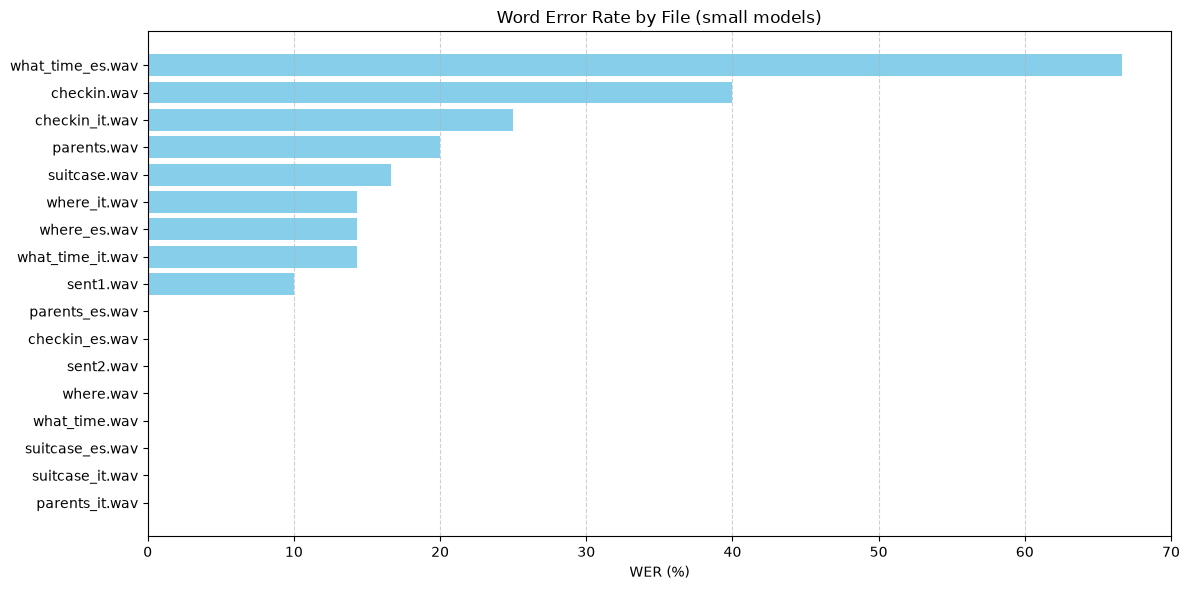

In [9]:
# Visualize WER with a bar chart
df_sorted = df.sort_values("WER (%)", ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(df_sorted["File"], df_sorted["WER (%)"], color="skyblue")
plt.xlabel("WER (%)")
plt.title(f"Word Error Rate by File ({MODEL_SIZE} models)")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
os.makedirs("docs", exist_ok=True)
plt.savefig(f"docs/wer-{MODEL_SIZE}.png", dpi=110)
plt.show()

## Does the filter help in noise?

The supplied clips are clean, so they cannot show whether the noise handling works. This test adds white noise at a signal-to-noise ratio of 10 dB (a seeded generator, so it is repeatable) and compares four conditions: the clip as it is or filtered, clean or noisy.

In [10]:
def add_noise(in_path, out_path, snr_db=10, seed=0):
    """Add white Gaussian noise at the given signal-to-noise ratio to a mono 16-bit WAV."""
    rng = np.random.default_rng(seed)
    with wave.open(in_path, "rb") as w:
        params = w.getparams()
        samples = np.frombuffer(w.readframes(w.getnframes()), dtype=np.int16).astype(np.float64)
    noise_power = np.mean(samples ** 2) / 10 ** (snr_db / 10)
    noisy = np.clip(samples + rng.normal(0, np.sqrt(noise_power), samples.shape), -32768, 32767).astype(np.int16)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with wave.open(out_path, "wb") as w:
        w.setparams(params)
        w.writeframes(noisy.tobytes())

# the unfiltered clip for every phrase (my own recordings are the converted files)
def raw_path(file):
    own_recording = file in ("EN/sent1.wav", "EN/sent2.wav")
    return os.path.join("output/filtered" if own_recording else "data", file)

for file in references:
    add_noise(raw_path(file), os.path.join("output/noise_test/noisy", file))
    apply_filters(raw_path(file), os.path.join("output/noise_test/clean_filtered", file))
    apply_filters(os.path.join("output/noise_test/noisy", file), os.path.join("output/noise_test/noisy_filtered", file))

conditions = {
    "Clean": lambda f: raw_path(f),
    "Clean + filter": lambda f: os.path.join("output/noise_test/clean_filtered", f),
    "Noisy": lambda f: os.path.join("output/noise_test/noisy", f),
    "Noisy + filter": lambda f: os.path.join("output/noise_test/noisy_filtered", f),
}

In [11]:
rows = []
for lang in languages:
    model = load_model(lang)
    for file, reference in references.items():
        if not file.startswith(lang + "/"):
            continue
        for name, path_of in conditions.items():
            transcript = transcribe_audio(path_of(file), model)
            rows.append({"Language": lang, "File": file, "Condition": name,
                         "WER (%)": wer(transform(reference), transform(transcript)) * 100})
    del model
    gc.collect()

noise_df = pd.DataFrame(rows)
noise_df.to_csv(f"results/noise_{MODEL_SIZE}.csv", index=False)

table = noise_df.pivot_table(index="Language", columns="Condition", values="WER (%)", aggfunc="mean")[list(conditions)]
table.loc["All"] = noise_df.groupby("Condition")["WER (%)"].mean()[list(conditions)]
table.round(1)

Condition,Clean,Clean + filter,Noisy,Noisy + filter
Language,,,,
EN,12.4,11.0,21.7,20.3
ES,9.5,16.2,46.5,39.4
IT,10.7,10.7,32.3,32.3
All,11.1,12.4,32.1,29.4


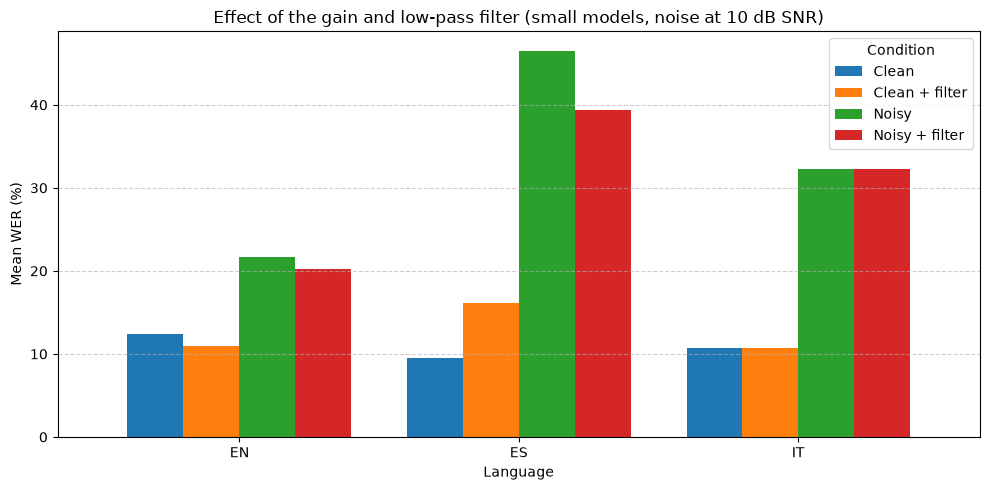

In [12]:
ax = table.drop(index="All").plot(kind="bar", figsize=(10, 5), rot=0, width=0.8)
ax.set_ylabel("Mean WER (%)")
ax.set_title(f"Effect of the gain and low-pass filter ({MODEL_SIZE} models, noise at 10 dB SNR)")
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(f"docs/noise-{MODEL_SIZE}.png", dpi=110)
plt.show()